TABELLA DEI RISULTATI DELL'ADDESTRAMENTO DI DIVERSI REGRESSORI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import sys
import re

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.set_printoptions(threshold=sys.maxsize)

INPUT_CSV = "[DL]best_models_summary_ordered.csv"


In [3]:
# Legge la tabella già pronta
best_models_df = pd.read_csv(INPUT_CSV)
# best_models_df


In [4]:
# 1. Arrotonda le colonne numeriche ai decimali corretti
best_models_df['R2_test'] = best_models_df['R2_test'].astype(float).apply(lambda x: f"{x:.6f}")
best_models_df['MAE_test'] = best_models_df['MAE_test'].astype(float).apply(lambda x: f"{x:.6f}")
best_models_df['ME_test'] = best_models_df['ME_test'].astype(float).apply(lambda x: f"{x:.6f}")
best_models_df['MAPE_test'] = best_models_df['MAPE_test'].astype(float).apply(lambda x: f"{x:.2f}%")
best_models_df['MSE_test'] = best_models_df['MSE_test'].astype(float).apply(lambda x: f"{x:.6f}")
best_models_df['RMSE_test'] = best_models_df['RMSE_test'].astype(float).apply(lambda x: f"{x:.6f}")
best_models_df['Train_Last_Epoch_Loss'] = best_models_df['Train_Last_Epoch_Loss'].astype(float).apply(lambda x: f"{x:.6f}")

In [5]:
# 1. Identifichiamo e droppiamo tutte le colonne che iniziano per "Filename" o "filename"
colonne_da_eliminare = [col for col in best_models_df.columns if col.lower().startswith('filename')]
df_elaborato = best_models_df.drop(columns=colonne_da_eliminare, errors='ignore')

df_elaborato = df_elaborato.drop(columns=["Numero parametri","DimensioneModelloF32", "DimensioneModelloInt8","Batch_Size", "Dropout", "Learning_Rate","Kernel_Size"], errors='ignore')

# 2. Rimuove le colonne che terminano per "_training" (case-insensitive, per sicurezza)
df_elaborato = df_elaborato.loc[:, ~df_elaborato.columns.str.lower().str.endswith('_train')]

# 3. Rimuove la colonna "ModelType" (non deve comparire nella tabella finale)
df_elaborato = df_elaborato.drop(columns=['ModelType'], errors='ignore')


In [6]:
# Converte le colonne "Dimensione*" in KB se < 0.10 MB, altrimenti in MB
colonne_dimensione = [col for col in df_elaborato.columns if col.startswith('Dimensione')]

for col in colonne_dimensione:
    df_elaborato[col] = df_elaborato[col].astype(float).map(
        lambda x: f"{round(x / 1024, 2)} KB" if (x / (1024 * 1024)) < 0.10 else f"{round(x / (1024 * 1024), 2)} MB"
    )

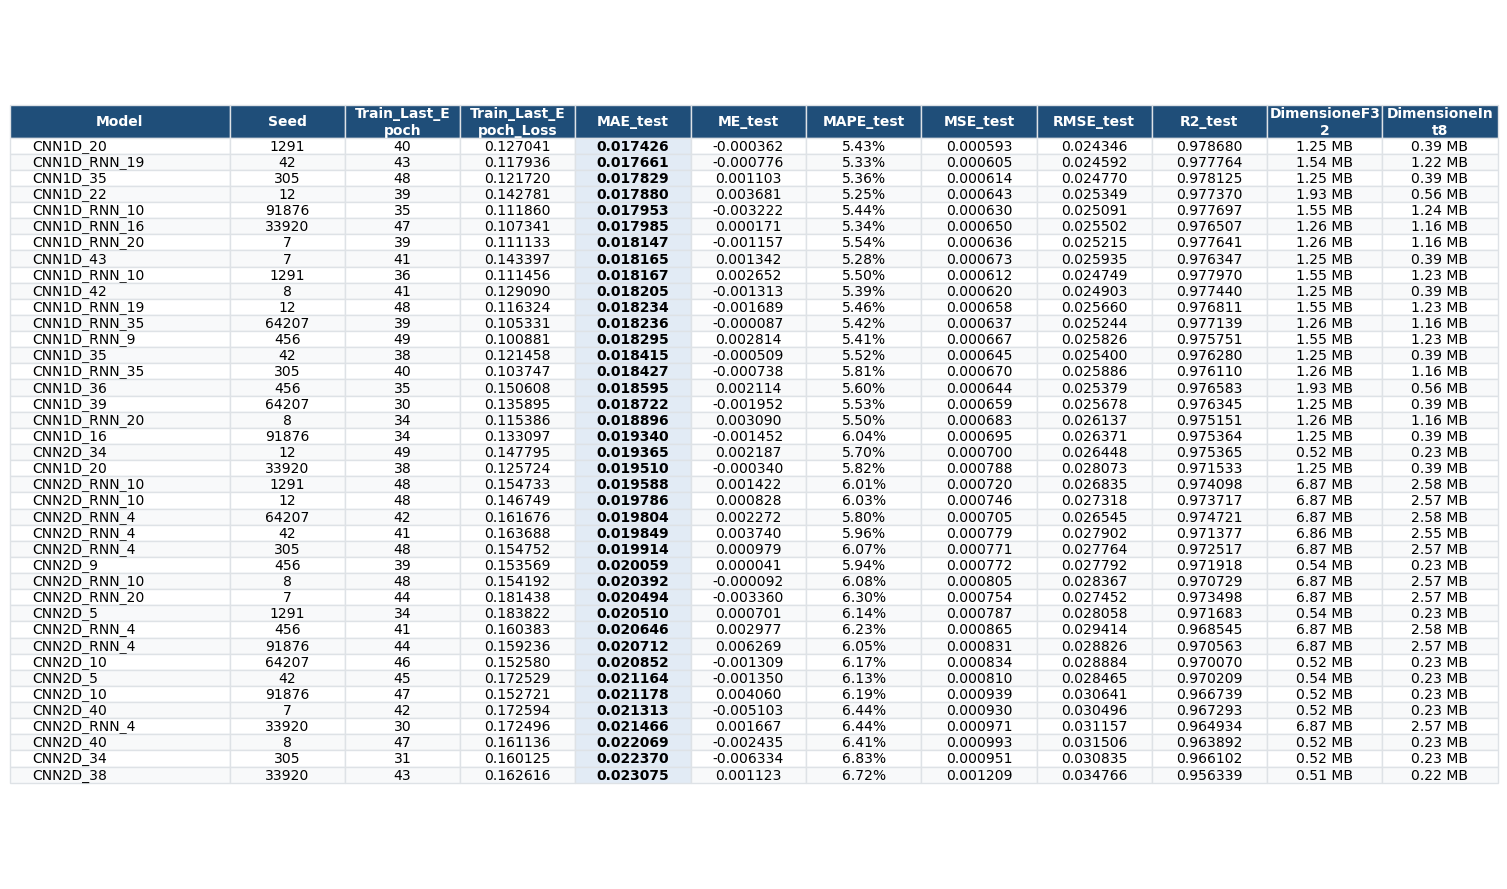

In [7]:
columns = df_elaborato.columns.tolist()
data_da_df = df_elaborato.values

# Proporzioni della figura (aumentata leggermente l'altezza per dare più respiro)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis('off')

# Gestione dinamica delle larghezze delle colonne
num_cols = len(columns)
col_widths = []

# --- MODIFICA MIRATA: Stretto il campo Iperparametri ---
w_modello = 0.16        # Rimane invariato ed esteso
spazio_rimanente = 1.0 - w_modello

for i in range(num_cols):
    if i == 0:
        col_widths.append(w_modello)
    else:
        # Distribuzione equa dello spazio restante tra le altre metriche
        col_widths.append(spazio_rimanente / (num_cols - 2))
# -------------------------------------------------------------------------------

# Creazione della tabella
tabella = ax.table(cellText=data_da_df, colLabels=columns, loc='center', cellLoc='left', colWidths=col_widths)
tabella.auto_set_font_size(False)

# Dizionario per salvare il numero massimo di linee di testo per OGNI riga
righe_altezze_testo = {}

# --- PRIMO PASSAGGIO: WRAPPING INTELLIGENTE E CALCOLO DELLE LINEE ---
for (row, col), cell in tabella.get_celld().items():
    cell.set_fontsize(10)
    cell.set_edgecolor('#dee2e6')

    testo_originale = str(cell.get_text().get_text())

    # Formattazione Intestazioni (Riga 0)
    if row == 0:
        # Gestione larghezza caratteri proporzionata ai nuovi spazi
        if col == 0:
            larghezza_caratteri = 18
        else:
            larghezza_caratteri = 12

        linee_header = textwrap.wrap(
            testo_originale,
            width=larghezza_caratteri,
            break_long_words=True,
            break_on_hyphens=True
        )
        testo_formattato_header = "\n".join(linee_header)
        cell.get_text().set_text(testo_formattato_header)

        # Memorizziamo quante linee di testo ci sono nell'header di questa colonna
        righe_altezze_testo[row] = max(righe_altezze_testo.get(row, 1), len(linee_header))

# --- SECONDO PASSAGGIO: APPLICAZIONE ALTEZZE E STILI ---
totale_righe_tabella = len(data_da_df) + 1
coeff_altezza = 0.35 / totale_righe_tabella

for (row, col), cell in tabella.get_celld().items():
    # Assegnazione dell'altezza dinamica basata sul testo reale contenuto
    linee_presenti = righe_altezze_testo.get(row, 1)

    if row == 0:
        # L'header ha bisogno di un moltiplicatore maggiore per non toccare i bordi superiori/inferiori
        cell.set_height((linee_presenti * coeff_altezza) + 0.02)
        cell.set_text_props(color='white', weight='bold', ha='center', va='center', linespacing=1.2)
        cell.set_facecolor('#1f4e79')
    else:
        # Righe di dati
        if row in righe_altezze_testo:
            cell.set_height((linee_presenti * coeff_altezza) + 0.015)
        else:
            # Altezza standard per righe a linea singola, proporzionata al box complessivo
            cell.set_height(coeff_altezza + 0.01)

        # Allineamenti interni del testo
        if col < 1:
            cell.set_text_props(ha='left', va='center')
        else:
            cell.set_text_props(ha='center', va='center')

        # Colorazione colonne speciali (MAE e Dimensione)
        if col == 4:  #or col == 6 or col == 7:
            cell.set_facecolor('#e2ebf5')
            cell.get_text().set_weight('bold')
        else:
            colore_sfondo = '#f8f9fa' if row % 2 == 0 else 'white'
            cell.set_facecolor(colore_sfondo)

plt.tight_layout()
plt.savefig("tabella_risultati.png", dpi=300, bbox_inches='tight')
plt.show()


In [8]:

# Deriviamo la tipologia di modello dalla colonna "Model"
# (es. "CNN1D_12" -> "CNN1D", "CNN2D_RNN_7" -> "CNN2D_RNN")
def estrai_tipologia_modello(nome):
    match = re.match(r"^(.*?)_\d+$", str(nome))
    return match.group(1) if match else str(nome)

df_elaborato["_ModelType"] = df_elaborato["Model"].apply(estrai_tipologia_modello)
df_elaborato["_MAE_sort"] = pd.to_numeric(df_elaborato["MAE_test"], errors="coerce")

tipologie_modello = sorted(df_elaborato["_ModelType"].dropna().unique().tolist())
print(f"Tipologie di modello trovate ({len(tipologie_modello)}): {tipologie_modello}")


Tipologie di modello trovate (4): ['CNN1D', 'CNN1D_RNN', 'CNN2D', 'CNN2D_RNN']


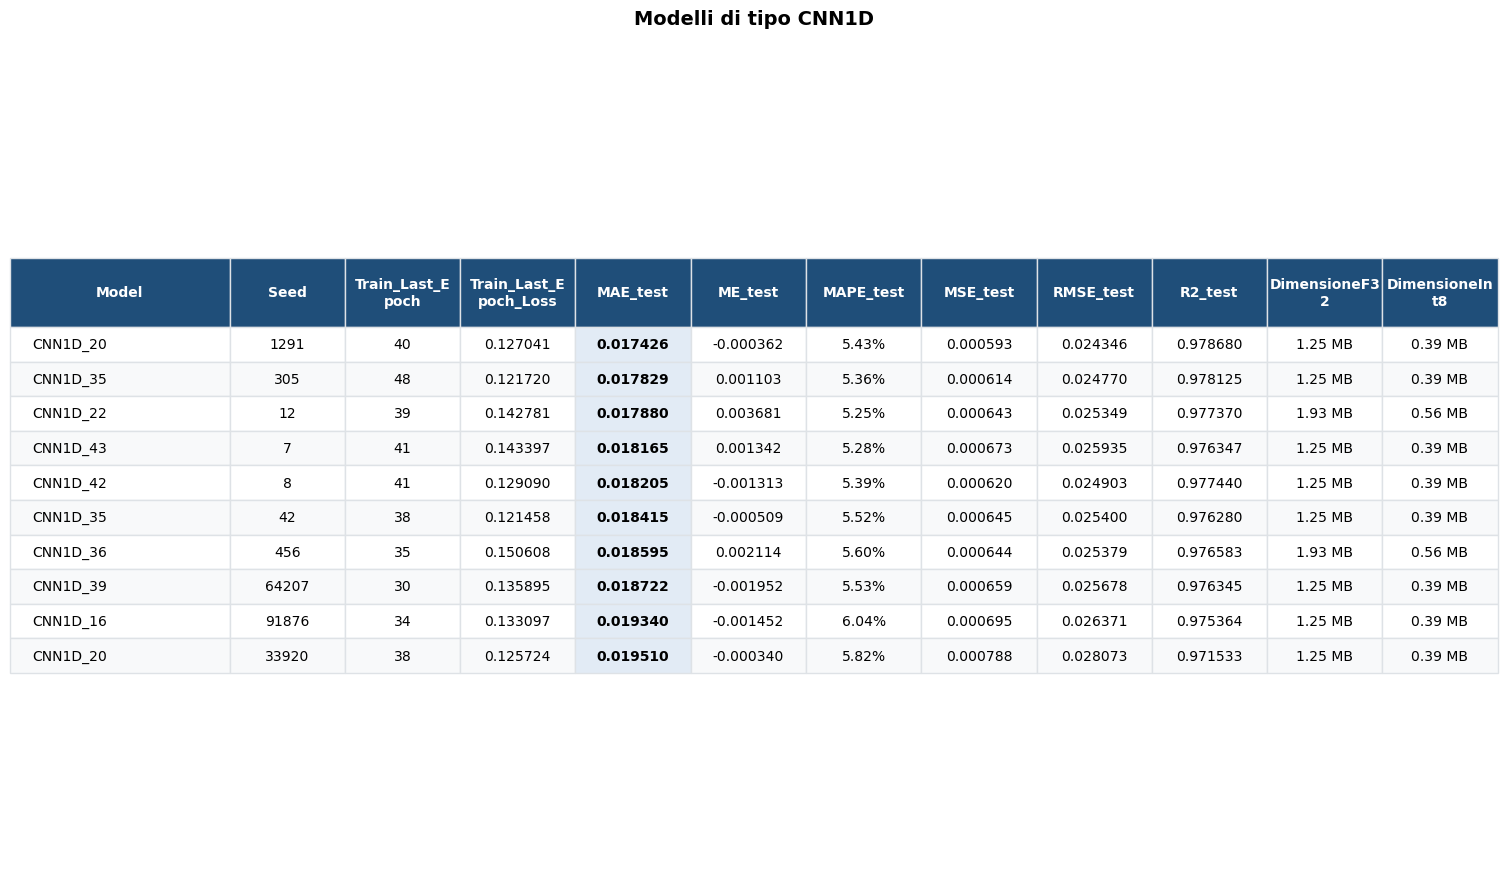

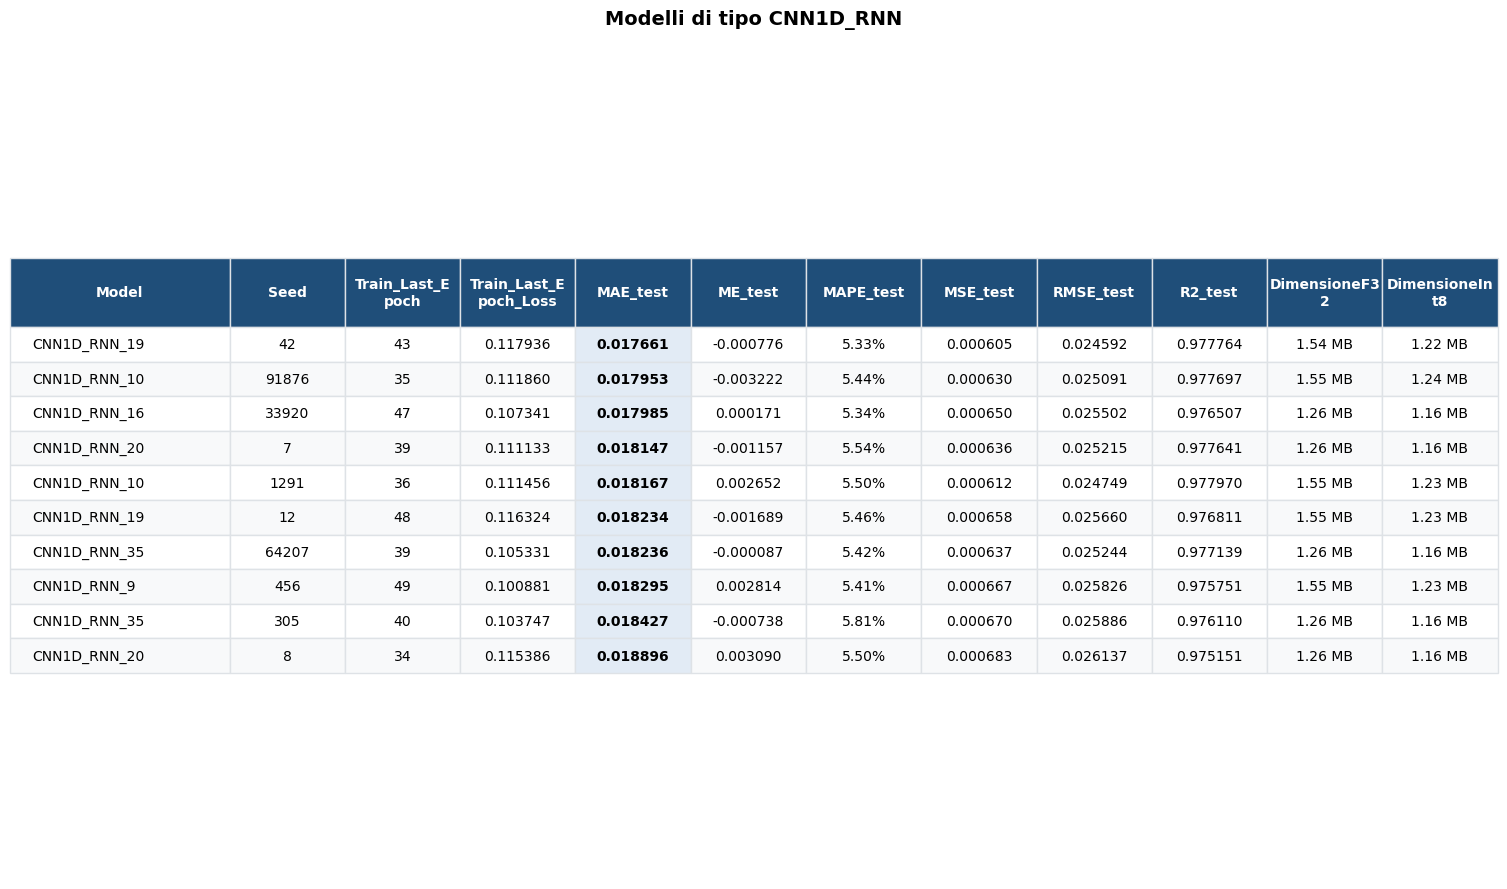

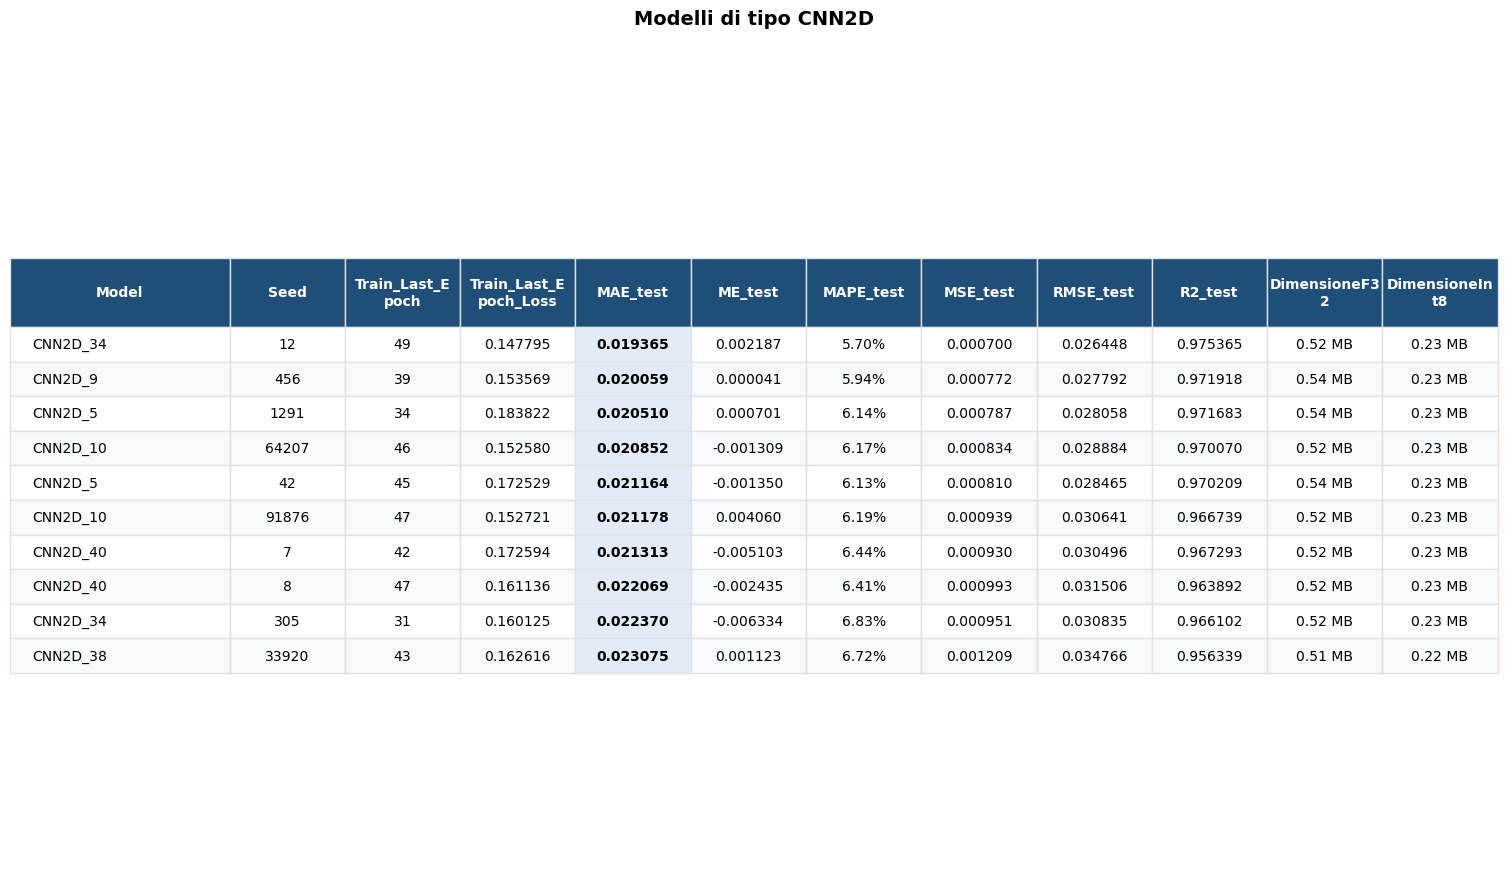

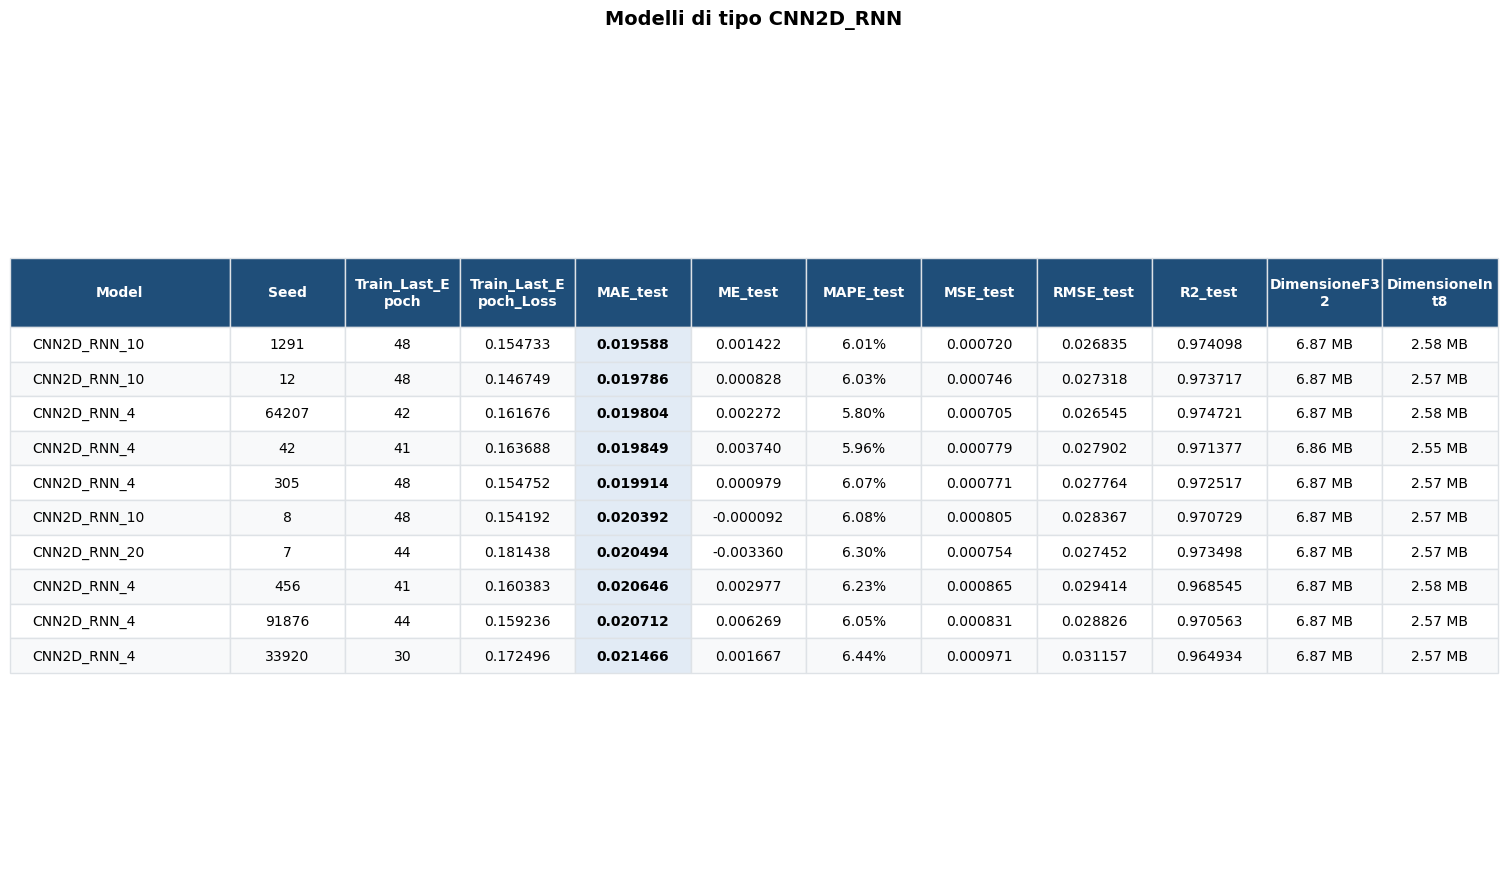

In [9]:
for tipo in tipologie_modello:
    df_elaborato_tipo = (
        df_elaborato[df_elaborato["_ModelType"] == tipo]
        .sort_values(by="_MAE_sort")
        .drop(columns=["_ModelType", "_MAE_sort"])
    )

    columns = df_elaborato_tipo.columns.tolist()
    data_da_df = df_elaborato_tipo.values

    # Proporzioni della figura (aumentata leggermente l'altezza per dare più respiro)
    fig, ax = plt.subplots(figsize=(15, 9))
    ax.axis('off')
    ax.set_title(f"Modelli di tipo {tipo}", fontsize=14, fontweight='bold', pad=20)

    # Gestione dinamica delle larghezze delle colonne
    num_cols = len(columns)
    col_widths = []

    # --- MODIFICA MIRATA: Stretto il campo Iperparametri ---
    w_modello = 0.16        # Rimane invariato ed esteso
    spazio_rimanente = 1.0 - w_modello

    for i in range(num_cols):
        if i == 0:
            col_widths.append(w_modello)
        else:
            # Distribuzione equa dello spazio restante tra le altre metriche
            col_widths.append(spazio_rimanente / (num_cols - 2))
    # -------------------------------------------------------------------------------

    # Creazione della tabella
    tabella = ax.table(cellText=data_da_df, colLabels=columns, loc='center', cellLoc='left', colWidths=col_widths)
    tabella.auto_set_font_size(False)

    # Dizionario per salvare il numero massimo di linee di testo per OGNI riga
    righe_altezze_testo = {}

    # --- PRIMO PASSAGGIO: WRAPPING INTELLIGENTE E CALCOLO DELLE LINEE ---
    for (row, col), cell in tabella.get_celld().items():
        cell.set_fontsize(10)
        cell.set_edgecolor('#dee2e6')

        testo_originale = str(cell.get_text().get_text())

        # Formattazione Intestazioni (Riga 0)
        if row == 0:
            # Gestione larghezza caratteri proporzionata ai nuovi spazi
            if col == 0:
                larghezza_caratteri = 18
            else:
                larghezza_caratteri = 12

            linee_header = textwrap.wrap(
                testo_originale,
                width=larghezza_caratteri,
                break_long_words=True,
                break_on_hyphens=True
            )
            testo_formattato_header = "\n".join(linee_header)
            cell.get_text().set_text(testo_formattato_header)

            # Memorizziamo quante linee di testo ci sono nell'header di questa colonna
            righe_altezze_testo[row] = max(righe_altezze_testo.get(row, 1), len(linee_header))

    # --- SECONDO PASSAGGIO: APPLICAZIONE ALTEZZE E STILI ---
    totale_righe_tabella = len(data_da_df) + 1
    coeff_altezza = 0.35 / totale_righe_tabella

    for (row, col), cell in tabella.get_celld().items():
        # Assegnazione dell'altezza dinamica basata sul testo reale contenuto
        linee_presenti = righe_altezze_testo.get(row, 1)

        if row == 0:
            # L'header ha bisogno di un moltiplicatore maggiore per non toccare i bordi superiori/inferiori
            cell.set_height((linee_presenti * coeff_altezza) + 0.02)
            cell.set_text_props(color='white', weight='bold', ha='center', va='center', linespacing=1.2)
            cell.set_facecolor('#1f4e79')
        else:
            # Righe di dati
            if row in righe_altezze_testo:
                cell.set_height((linee_presenti * coeff_altezza) + 0.015)
            else:
                # Altezza standard per righe a linea singola, proporzionata al box complessivo
                cell.set_height(coeff_altezza + 0.01)

            # Allineamenti interni del testo
            if col < 1:
                cell.set_text_props(ha='left', va='center')
            else:
                cell.set_text_props(ha='center', va='center')

            # Colorazione colonne speciali (MAE e Dimensione)
            if col == 4:  #or col == 6 or col == 7:
                cell.set_facecolor('#e2ebf5')
                cell.get_text().set_weight('bold')
            else:
                colore_sfondo = '#f8f9fa' if row % 2 == 0 else 'white'
                cell.set_facecolor(colore_sfondo)

    plt.tight_layout()
    plt.savefig(f"tabella_risultati_{tipo}.png", dpi=300, bbox_inches='tight')
    plt.show()
